# Crop Recommendation 

## 1. Imports

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import warnings
warnings.filterwarnings('ignore')

print('All imports successful ✅')

All imports successful ✅


## 2. Load Data

In [16]:
# Update this path to your actual file location
df = pd.read_csv(r"c:\\Users\A S P I R E 7\\Desktop\python_practice\\cROP RECOMENDATION DATA\\Crop Recommendation using Soil Properties and Weather Prediction.csv")

# Rename columns for clarity
df.rename(columns={
    'QV2M-W': 'humidity_winter',
    'QV2M-Sp': 'humidity_spring',
    'QV2M-Su': 'humidity_summer',
    'QV2M-Au': 'humidity_autumn',
    'PRECTOTCORR-W': 'precip_winter',
    'PRECTOTCORR-Sp': 'precip_spring',
    'PRECTOTCORR-Su': 'precip_summer',
    'PRECTOTCORR-Au': 'precip_autumn',
    'WD10M': 'wind_dir_10m',
    'GWETTOP': 'ground_wetness_top',
    'CLOUD_AMT': 'cloud_amount',
    'WS2M_RANGE': 'wind_speed_range_2m',
    'PS': 'surface_pressure',
    'label': 'crop_label'
}, inplace=True)

print(f'Shape: {df.shape}')
df.head(3)

Shape: (3867, 29)


,Soilcolor,Ph,K,P,N,Zn,S,humidity_winter,humidity_spring,humidity_summer,...,precip_winter,precip_spring,precip_summer,precip_autumn,wind_dir_10m,ground_wetness_top,cloud_amount,wind_speed_range_2m,surface_pressure,crop_label
0,Yellowish brown,5.81,738.231,5.401,0.23,2.976,13.816,7.993333,10.456667,11.963333,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
1,Yellowish brown,5.43,606.382,10.478,0.23,3.077,16.421,7.993333,10.456667,11.963333,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley
2,brown,5.41,386.580,6.847,0.23,6.611,16.557,7.993333,10.456667,11.963333,...,2.073333,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,Barley


## 3. Exploratory Data Analysis

In [17]:
print('=== Basic Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print(f'\n=== Duplicate Rows: {df.duplicated().sum()} ===')

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3867 entries, 0 to 3866
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Soilcolor            3867 non-null   object 
 1   Ph                   3867 non-null   float64
 2   K                    3867 non-null   float64
 3   P                    3867 non-null   float64
 4   N                    3867 non-null   float64
 5   Zn                   3867 non-null   float64
 6   S                    3867 non-null   float64
 7   humidity_winter      3867 non-null   float64
 8   humidity_spring      3867 non-null   float64
 9   humidity_summer      3867 non-null   float64
 10  humidity_autumn      3867 non-null   float64
 11  T2M_MAX-W            3867 non-null   float64
 12  T2M_MAX-Sp           3867 non-null   float64
 13  T2M_MAX-Su           3867 non-null   float64
 14  T2M_MAX-Au           3867 non-null   float64
 15  T2M_MIN-W          

In [18]:
print('Crop distribution:')
print(df['crop_label'].value_counts())
print('\nSoil color distribution:')
print(df['Soilcolor'].value_counts())

Crop distribution:
crop_label
Teff          1260
Maize          732
Wheat          715
Barley         503
Bean           253
Pea             94
Sorghum         72
Dagussa         71
Niger seed      64
Potato          48
Red Pepper      29
Fallow          26
Name: count, dtype: int64

Soil color distribution:
Soilcolor
brown                                              1297
red                                                1195
black                                               860
other                                               128
gray                                                 88
reddish brown                                        85
dark brown                                           51
dark gray                                            35
Reddish brown                                        14
dark reddish brown                                   13
Red                                                  11
Dark brown                                            9
darkbrow

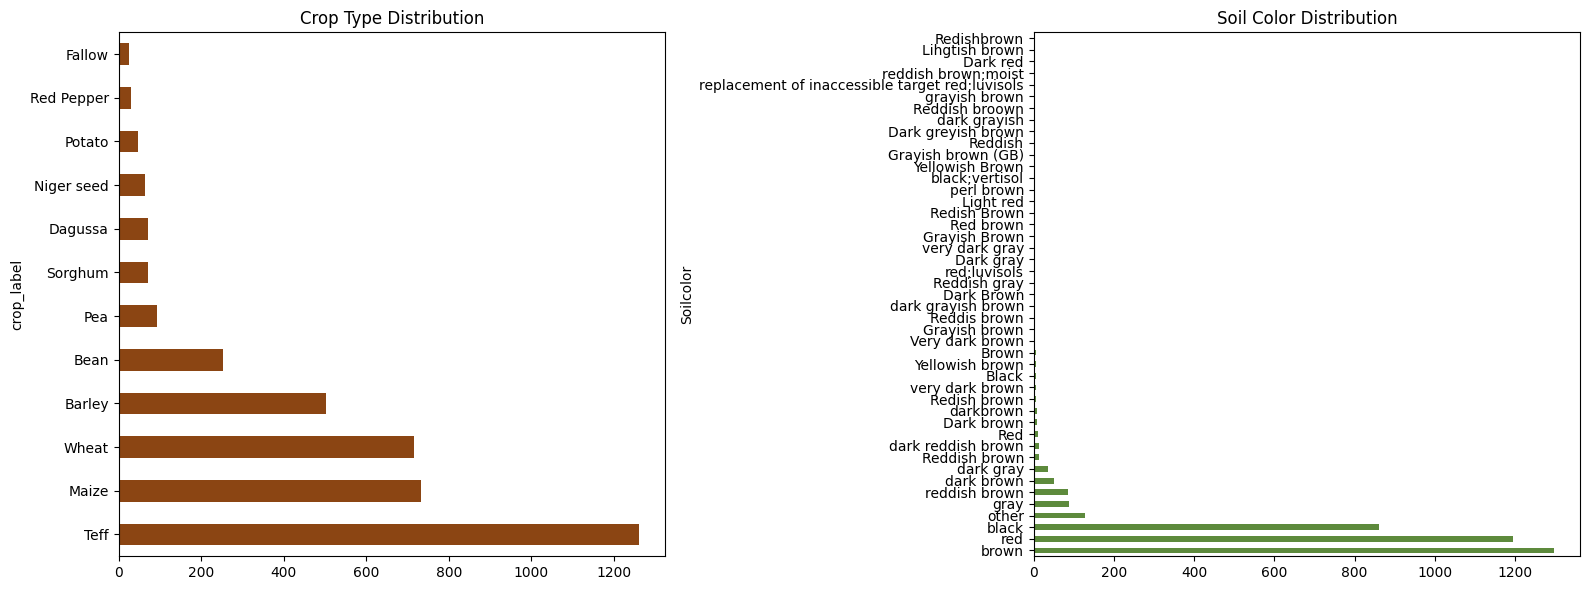

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df['crop_label'].value_counts().plot(kind='barh', ax=axes[0], color='#8B4513')
axes[0].set_title('Crop Type Distribution')
df['Soilcolor'].value_counts().plot(kind='barh', ax=axes[1], color='#5D8A3C')
axes[1].set_title('Soil Color Distribution')
plt.tight_layout()
plt.show()

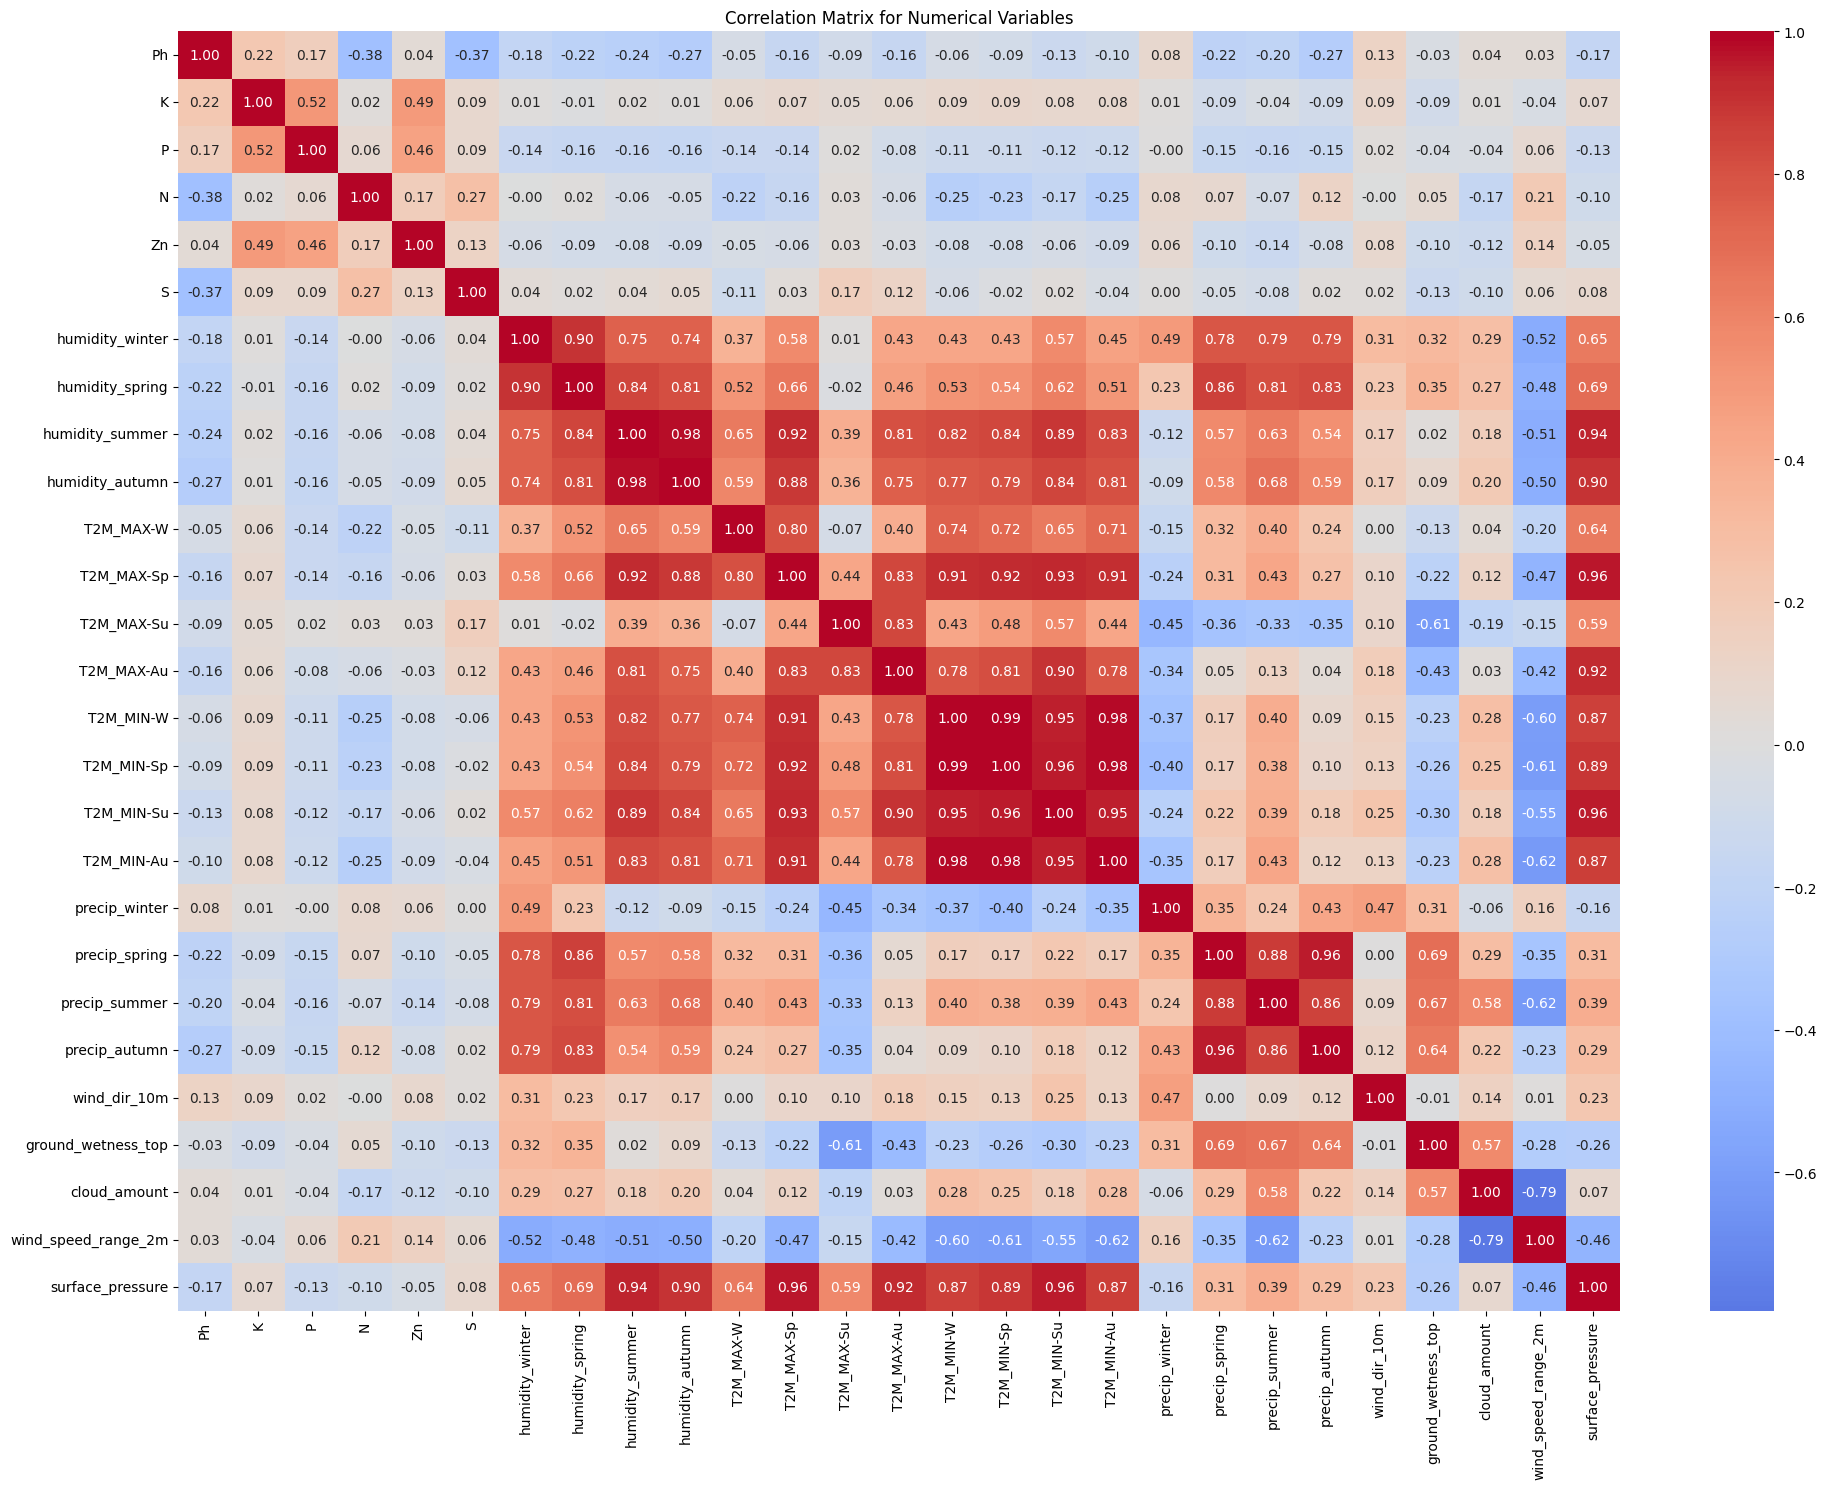

In [20]:
numerical_cols = ['Ph', 'K', 'P', 'N', 'Zn', 'S',
                  'humidity_winter', 'humidity_spring', 'humidity_summer', 'humidity_autumn',
                  'T2M_MAX-W', 'T2M_MAX-Sp', 'T2M_MAX-Su', 'T2M_MAX-Au',
                  'T2M_MIN-W', 'T2M_MIN-Sp', 'T2M_MIN-Su', 'T2M_MIN-Au',
                  'precip_winter', 'precip_spring', 'precip_summer', 'precip_autumn',
                  'wind_dir_10m', 'ground_wetness_top', 'cloud_amount',
                  'wind_speed_range_2m', 'surface_pressure']

# Only keep columns that actually exist in df
numerical_cols = [c for c in numerical_cols if c in df.columns]

plt.figure(figsize=(20, 15))
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix for Numerical Variables')
plt.tight_layout()
plt.show()

## 4. Preprocessing
### FIX: Use LabelEncoder for crop_label (consistent, avoids typos)

In [21]:
data = df.copy()

# FIX 6: Use LabelEncoder instead of manual dict for crop
le_crop = LabelEncoder()
data['crop'] = le_crop.fit_transform(data['crop_label'])
print('Crop label mapping:')
for i, cls in enumerate(le_crop.classes_):
    print(f'  {i}: {cls}')

# Encode Soilcolor
le_soil = LabelEncoder()
data['Soilcolor_types'] = le_soil.fit_transform(data['Soilcolor'])

# Drop original string columns
data.drop(['crop_label', 'Soilcolor'], axis=1, inplace=True)

print(f'\nFinal shape: {data.shape}')
data.head(3)

Crop label mapping:
  0: Barley
  1: Bean
  2: Dagussa
  3: Fallow
  4: Maize
  5: Niger seed
  6: Pea
  7: Potato
  8: Red Pepper
  9: Sorghum
  10: Teff
  11: Wheat

Final shape: (3867, 29)


,Ph,K,P,N,Zn,S,humidity_winter,humidity_spring,humidity_summer,humidity_autumn,...,precip_spring,precip_summer,precip_autumn,wind_dir_10m,ground_wetness_top,cloud_amount,wind_speed_range_2m,surface_pressure,crop,Soilcolor_types
0,5.81,738.231,5.401,0.23,2.976,13.816,7.993333,10.456667,11.963333,9.683333,...,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,0,24
1,5.43,606.382,10.478,0.23,3.077,16.421,7.993333,10.456667,11.963333,9.683333,...,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,0,24
2,5.41,386.580,6.847,0.23,6.611,16.557,7.993333,10.456667,11.963333,9.683333,...,5.27,12.303333,5.27,3.44,0.73,56.57,6.24,77.03,0,27


## 5. Train/Test Split
###  FIX: Split FIRST, then scale inside Pipeline to prevent data leakage

In [22]:
X = data.drop('crop', axis=1)
y = data['crop']

print(f'Features: {X.shape[1]}, Samples: {X.shape[0]}')
print(f'Classes: {y.nunique()}')

# Stratified split to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Features: 28, Samples: 3867
Classes: 12
Train: (3093, 28), Test: (774, 28)


## 6. Model Training with Pipelines
### FIX: Use Pipeline so scaler is fit ONLY on training data (no leakage!)
### FIX: Add cross-validation for reliable performance estimates

In [23]:
# Define models inside Pipelines — scaler fit only on train fold each time
pipelines = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42))
    ]),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42, n_estimators=100))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print(f'{'Model':<25} {'CV Mean Acc':>12} {'CV Std':>10} {'Test Acc':>10}')
print('-' * 60)

for name, pipe in pipelines.items():
    # Cross-validation on training data
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    
    # Fit on full train, evaluate on test
    pipe.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, pipe.predict(X_test))
    
    results[name] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'test_acc': test_acc,
        'pipeline': pipe
    }
    print(f'{name:<25} {cv_scores.mean():>12.4f} {cv_scores.std():>10.4f} {test_acc:>10.4f}')

Model                      CV Mean Acc     CV Std   Test Acc
------------------------------------------------------------
Logistic Regression             0.4678     0.0083     0.4638
SVM                             0.4888     0.0101     0.4871
KNN                             0.4543     0.0060     0.4729
Decision Tree                   0.3686     0.0101     0.3811
Random Forest                   0.4927     0.0169     0.5194
Gradient Boosting               0.4782     0.0156     0.4793


## 7. Visualize Model Comparison

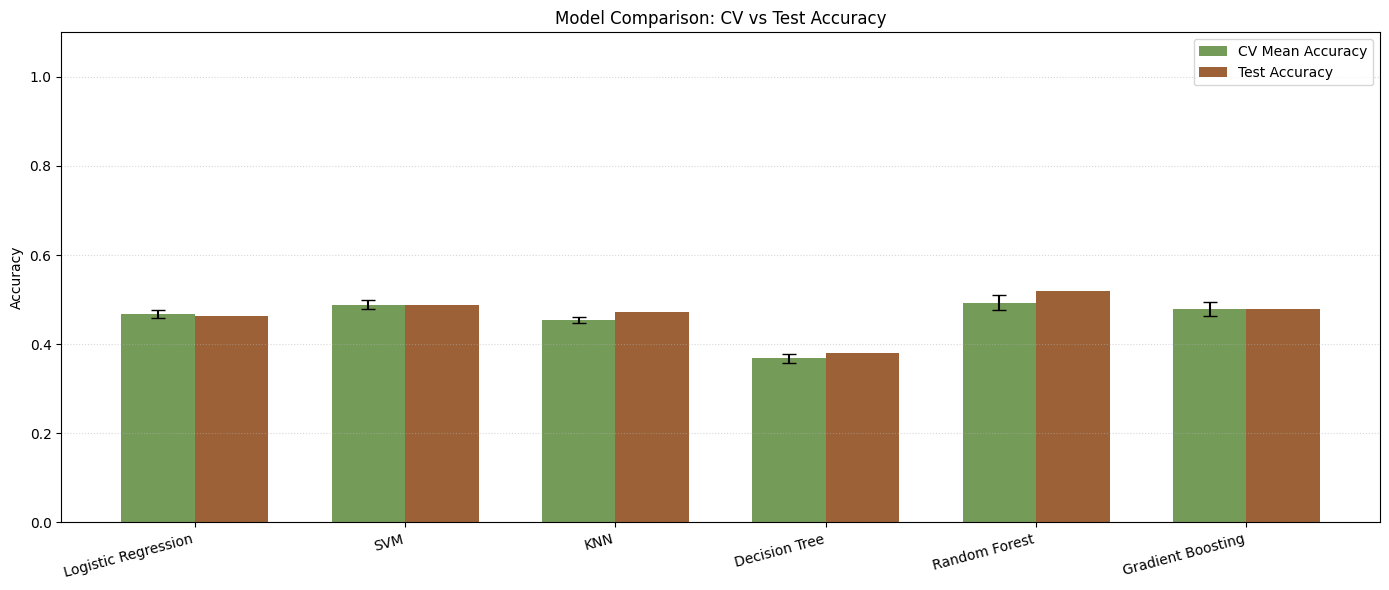

In [24]:
names = list(results.keys())
cv_means = [results[n]['cv_mean'] for n in names]
cv_stds = [results[n]['cv_std'] for n in names]
test_accs = [results[n]['test_acc'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, cv_means, width, yerr=cv_stds, label='CV Mean Accuracy', 
               capsize=5, color='#5D8A3C', alpha=0.85)
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Accuracy', 
               color='#8B4513', alpha=0.85)

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison: CV vs Test Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Best Model Detailed Evaluation
###  FIX: Full classification report, not just accuracy

In [25]:
best_name = max(results, key=lambda n: results[n]['cv_mean'])
best_pipe = results[best_name]['pipeline']
print(f'🏆 Best Model: {best_name}')
print(f'   CV Accuracy: {results[best_name]["cv_mean"]:.4f} ± {results[best_name]["cv_std"]:.4f}')
print(f'   Test Accuracy: {results[best_name]["test_acc"]:.4f}')

y_pred = best_pipe.predict(X_test)

print('\n=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le_crop.classes_))

🏆 Best Model: Random Forest
   CV Accuracy: 0.4927 ± 0.0169
   Test Accuracy: 0.5194

=== Classification Report ===
              precision    recall  f1-score   support

      Barley       0.46      0.42      0.44       101
        Bean       0.20      0.04      0.07        51
     Dagussa       0.33      0.14      0.20        14
      Fallow       0.00      0.00      0.00         5
       Maize       0.53      0.65      0.58       146
  Niger seed       0.00      0.00      0.00        13
         Pea       0.50      0.26      0.34        19
      Potato       0.25      0.10      0.14        10
  Red Pepper       0.00      0.00      0.00         6
     Sorghum       0.00      0.00      0.00        14
        Teff       0.57      0.75      0.65       252
       Wheat       0.49      0.45      0.47       143

    accuracy                           0.52       774
   macro avg       0.28      0.24      0.24       774
weighted avg       0.47      0.52      0.48       774



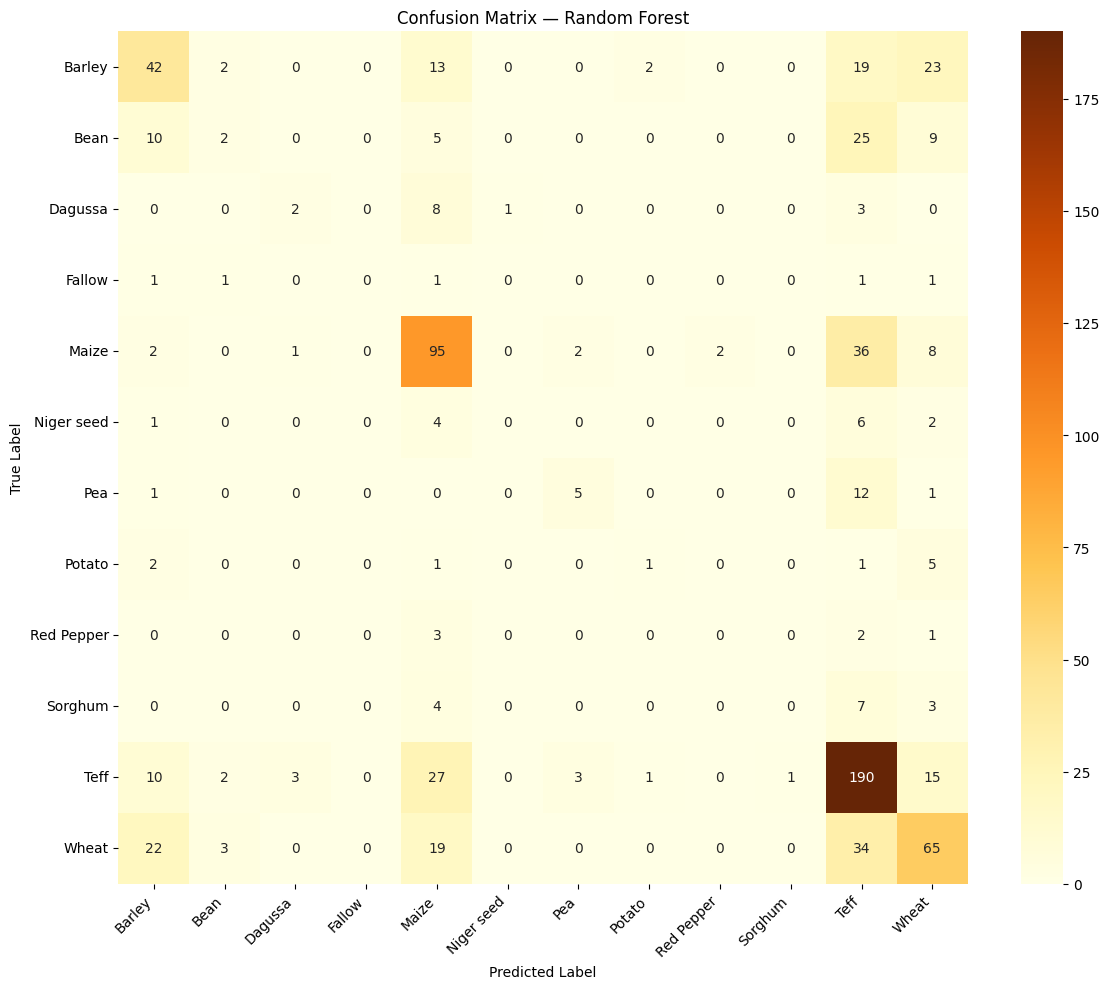

In [26]:
# FIX 3: Confusion matrix for the correct best model
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr',
            xticklabels=le_crop.classes_,
            yticklabels=le_crop.classes_)
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 9. Feature Importance 

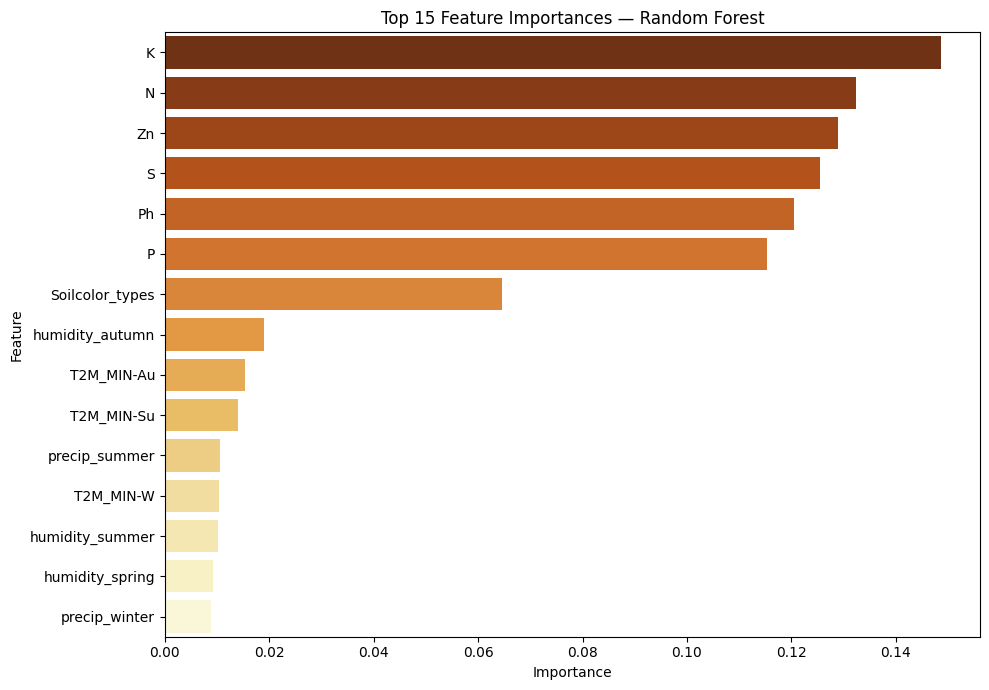

Top 5 most important features:
Feature  Importance
      K    0.148682
      N    0.132363
     Zn    0.128856
      S    0.125390
     Ph    0.120532


In [27]:
# Feature importance from Random Forest or Gradient Boosting
tree_model_name = 'Random Forest' if 'Random Forest' in results else 'Gradient Boosting'
tree_pipe = results[tree_model_name]['pipeline']
importances = tree_pipe.named_steps['model'].feature_importances_
feat_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(data=feat_df, x='Importance', y='Feature', palette='YlOrBr_r')
plt.title(f'Top 15 Feature Importances — {tree_model_name}')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_df.head(5).to_string(index=False))

## 10. Hyperparameter Tuning for Best Model 
###  FIX: Use GridSearchCV to find optimal hyperparameters

In [28]:
# Tune Random Forest as example (swap model name to tune others)
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
}

grid_search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f'\nBest params: {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')
print(f'Tuned test accuracy: {accuracy_score(y_test, grid_search.predict(X_test)):.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best params: {'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}
Best CV accuracy: 0.5118
Tuned test accuracy: 0.5142
